In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Problem 11: climate-related deaths

The Centre for Research on the Epidemiology of Disasters (CRED) within the University of Leuven maintains an [Emergency Events database](https://public.emdat.be/) covering over 20,000 mass disasters globally, starting from 1900.

In [2]:
# load Emergency Events data
path = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/emergency_events.csv'
data = pd.read_csv(path,index_col='Year')
data

,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,Country,Continent,Total Deaths
Year,,,,,,,
1900,Natural,Climatological,Drought,Drought,Cabo Verde,Africa,11000.0
1900,Natural,Climatological,Drought,Drought,India,Asia,1250000.0
1904,Natural,Meteorological,Storm,Tropical cyclone,Bangladesh,Asia,NaN
1906,Natural,Hydrological,Flood,NaN,Belgium,Europe,6.0
1906,Natural,Hydrological,Flood,NaN,Belgium,Europe,NaN
...,...,...,...,...,...,...,...
2022,Natural,Hydrological,Flood,NaN,Yemen,Asia,17.0
2022,Natural,Hydrological,Flood,NaN,South Africa,Africa,3.0
2022,Natural,Hydrological,Flood,NaN,South Africa,Africa,4.0


Compute the total number of deaths by year and disaster type. 
Assign the results to a new `DataFrame` named `deaths`

In [53]:
deaths= pd.pivot_table(data=data, values='Total Deaths', index=data.index, columns='Disaster Type', aggfunc='sum')

In [54]:
deaths = deaths.fillna(0)
deaths

Disaster Type,Drought,Extreme temperature,Flood,Storm
Year,,,,
1900,1261000.0,0.0,300.0,6000.0
1902,0.0,0.0,0.0,600.0
1903,0.0,0.0,250.0,163.0
1904,0.0,0.0,0.0,0.0
1905,0.0,0.0,0.0,240.0
...,...,...,...,...
2018,0.0,715.0,2881.0,1707.0
2019,85.0,2909.0,5149.0,2514.0
2020,45.0,6343.0,6185.0,1752.0


In [8]:
# load world population data as a Series (set `squeeze` parameter to True)
path = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/world_population.csv'
pop = pd.read_csv(path,index_col='Year',squeeze=True)
pop

Year
1900    1.647405e+09
1901    1.658786e+09
1902    1.672564e+09
1903    1.687013e+09
1904    1.701647e+09
            ...     
2018    7.631081e+09
2019    7.713458e+09
2020    7.794789e+09
2021    7.874956e+09
2022    7.953943e+09
Name: world_population, Length: 123, dtype: float64

Compute the total number of deaths by year and distaster type. 
Assign the results to a new DataFrame named `deaths`

I don't think you want me to do this here? I just did it above?

Plot the world population by year

<AxesSubplot:xlabel='Year'>

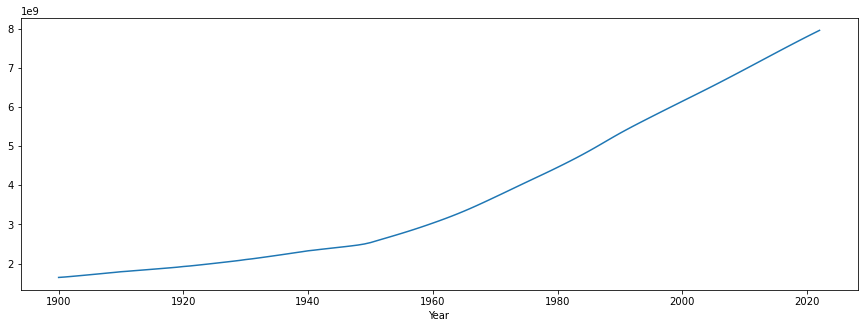

In [11]:
pop.plot(figsize=(15,5))

Compute the number of deaths per 100,000 population by year and disaster type.
Assign the results to a new DataFrame called `rel_deaths`.

Hint: you want to divide each row of the `deaths` DataFrame by the corresponding population.
To do this, you need to use the `.divide()` DataFrame method with the `axis` parameter set to 0.

In [57]:
rel_deaths = (deaths.divide(pop, axis=0)*1E5).fillna(0)
rel_deaths

Disaster Type,Drought,Extreme temperature,Flood,Storm
Year,,,,
1900,76.544625,0.000000,0.018210,0.364209
1901,0.000000,0.000000,0.000000,0.000000
1902,0.000000,0.000000,0.000000,0.035873
1903,0.000000,0.000000,0.014819,0.009662
1904,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...
2018,0.000000,0.009370,0.037753,0.022369
2019,0.001102,0.037713,0.066753,0.032592
2020,0.000577,0.081375,0.079348,0.022477


Calculate and plot the **decade** average annual number of deaths per 100,000 by disaster type. Use a bar plot.

Hint: group by `10*(rel_deaths.index//10)`

In [59]:
rel_deaths['decade']=10*(rel_deaths.index//10)

In [64]:
rel_deaths.columns

Index(['Drought', 'Extreme temperature', 'Flood', 'Storm', 'decade'], dtype='object', name='Disaster Type')

In [69]:
rel_deaths.groupby('decade').sum() # linearity of mean => can add individual year avgs to yield decade avg

Disaster Type,Drought,Extreme temperature,Flood,Storm
decade,,,,
1900,76.544625,0.000000,0.037428,1.058595
1910,4.739803,0.000000,5.617306,3.285832
1920,234.523834,0.000000,0.209904,6.099981
1930,0.000000,0.075805,203.379204,4.254288
1940,145.319135,0.000000,4.044216,5.359280
1950,0.000000,0.053765,69.393240,1.113757
1960,45.229222,0.034560,0.994275,4.099674
1970,3.031577,0.038301,1.754893,9.533219
1980,11.932444,0.111161,1.072401,0.949226


<AxesSubplot:xlabel='decade'>

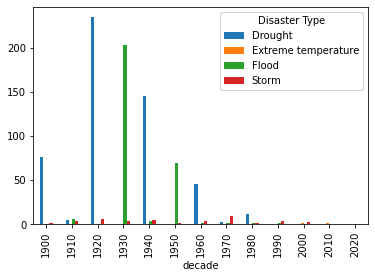

In [71]:
rel_deaths.groupby('decade').sum().plot.bar()